In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe
from astropy.stats import kuiper, kuiper_two

# import custom stuff
from ambpy.plotutils import make_figure_filename
plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = False

In [2]:
ds_max = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_min_1deg_landonly_gevfitted.nc')
ds_max_mle = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_max_1deg_landonly_gevfitted_mle.nc')

In [3]:
ds_max

<xarray.Dataset> Size: 42MB
Dimensions:     (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year        (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m         (year, lat, lon) float32 19MB ...
    t2m_anom    (year, lat, lon) float32 19MB ...
    shape_raw   (lat, lon) float64 518kB ...
    loc_raw     (lat, lon) float64 518kB ...
    scale_raw   (lat, lon) float64 518kB ...
    shape_anom  (lat, lon) float64 518kB ...
    loc_anom    (lat, lon) float64 518kB ...
    scale_anom  (lat, lon) float64 518kB ...

In [4]:
ds_max_mle

<xarray.Dataset> Size: 42MB
Dimensions:     (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year        (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m         (year, lat, lon) float32 19MB ...
    t2m_anom    (year, lat, lon) float32 19MB ...
    shape_raw   (lat, lon) float64 518kB ...
    loc_raw     (lat, lon) float64 518kB ...
    scale_raw   (lat, lon) float64 518kB ...
    shape_anom  (lat, lon) float64 518kB ...
    loc_anom    (lat, lon) float64 518kB ...
    scale_anom  (lat, lon) float64 518kB ...

In [5]:
# check bulk statistics between fitting to raw vs anomalies
describe(ds_max['shape_raw'].values.flatten()), describe(ds_max['shape_anom'].values.flatten())

(DescribeResult(nobs=64800, minmax=(nan, nan), mean=nan, variance=nan, skewness=nan, kurtosis=nan),
 DescribeResult(nobs=64800, minmax=(nan, nan), mean=nan, variance=nan, skewness=nan, kurtosis=nan))

In [10]:
np.nanmean(ds_max['shape_raw'].values.flatten()), np.nanmean(ds_max['scale_raw'].values.flatten()), np.nanmean(ds_max['loc_raw'].values.flatten())

(0.5174861789059877, 2.386194756502094, 247.266421146409)

In [11]:
np.nanmean(ds_max['shape_anom'].values.flatten()), np.nanmean(ds_max['scale_anom'].values.flatten()), np.nanmean(ds_max['loc_anom'].values.flatten())


(0.2499324109892281, 2.016958760224934, 20.09508905190582)

In [12]:
np.nanmean(ds_max_mle['shape_raw'].values.flatten()), np.nanmean(ds_max_mle['scale_raw'].values.flatten()), np.nanmean(ds_max_mle['loc_raw'].values.flatten())

(285.20706729446647, -0.23355743029953235, 1.543744257757079)

In [18]:
def plot_gev_parameters(ds, save_fig=True, filename_args=['gev-params', 'png', 'figs'], whoops=False):
    """
    Plot GEV parameters (shape, loc, scale) for both raw and anomaly data on a 2x3 world map grid.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing shape_raw, loc_raw, scale_raw, shape_anom, loc_anom, scale_anom
    save_fig : bool, optional
        If True, saves the figure.
    filename_args : list, optional
        Arguments for make_figure_filename function.
    """

    # Set up the 2x3 grid
    fig, axes = plt.subplots(
        nrows=2, ncols=3,
        figsize=(18, 10),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # Define the data and titles for each subplot
    raw_params = [ds['shape_raw'], ds['loc_raw'], ds['scale_raw']]
    anom_params = [ds['shape_anom'], ds['loc_anom'], ds['scale_anom']]

    if whoops:
        raw_params = [ds['scale_raw'], ds['shape_raw'], ds['loc_raw']]
        anom_params = [ds['scale_anom'], ds['shape_anom'], ds['loc_anom']]
    param_names = ["Shape", "Location", "Scale"]
    
    # Plot raw parameters on top row
    for col, (da, param_name) in enumerate(zip(raw_params, param_names)):
        ax = axes[0, col]
        
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            add_colorbar=False
        )

        # Add colorbar
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label(param_name)

        ax.set_title(f"GEV {param_name} (Raw)")

    # Plot anomaly parameters on bottom row
    for col, (da, param_name) in enumerate(zip(anom_params, param_names)):
        ax = axes[1, col]
        
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            add_colorbar=False
        )

        # Add colorbar
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label(param_name)

        ax.set_title(f"GEV {param_name} (Anomaly)")

    plt.tight_layout()
    if save_fig:
        plt.savefig(make_figure_filename(*filename_args), dpi=300, bbox_inches="tight")
        print('Figure saved!')
    plt.show()


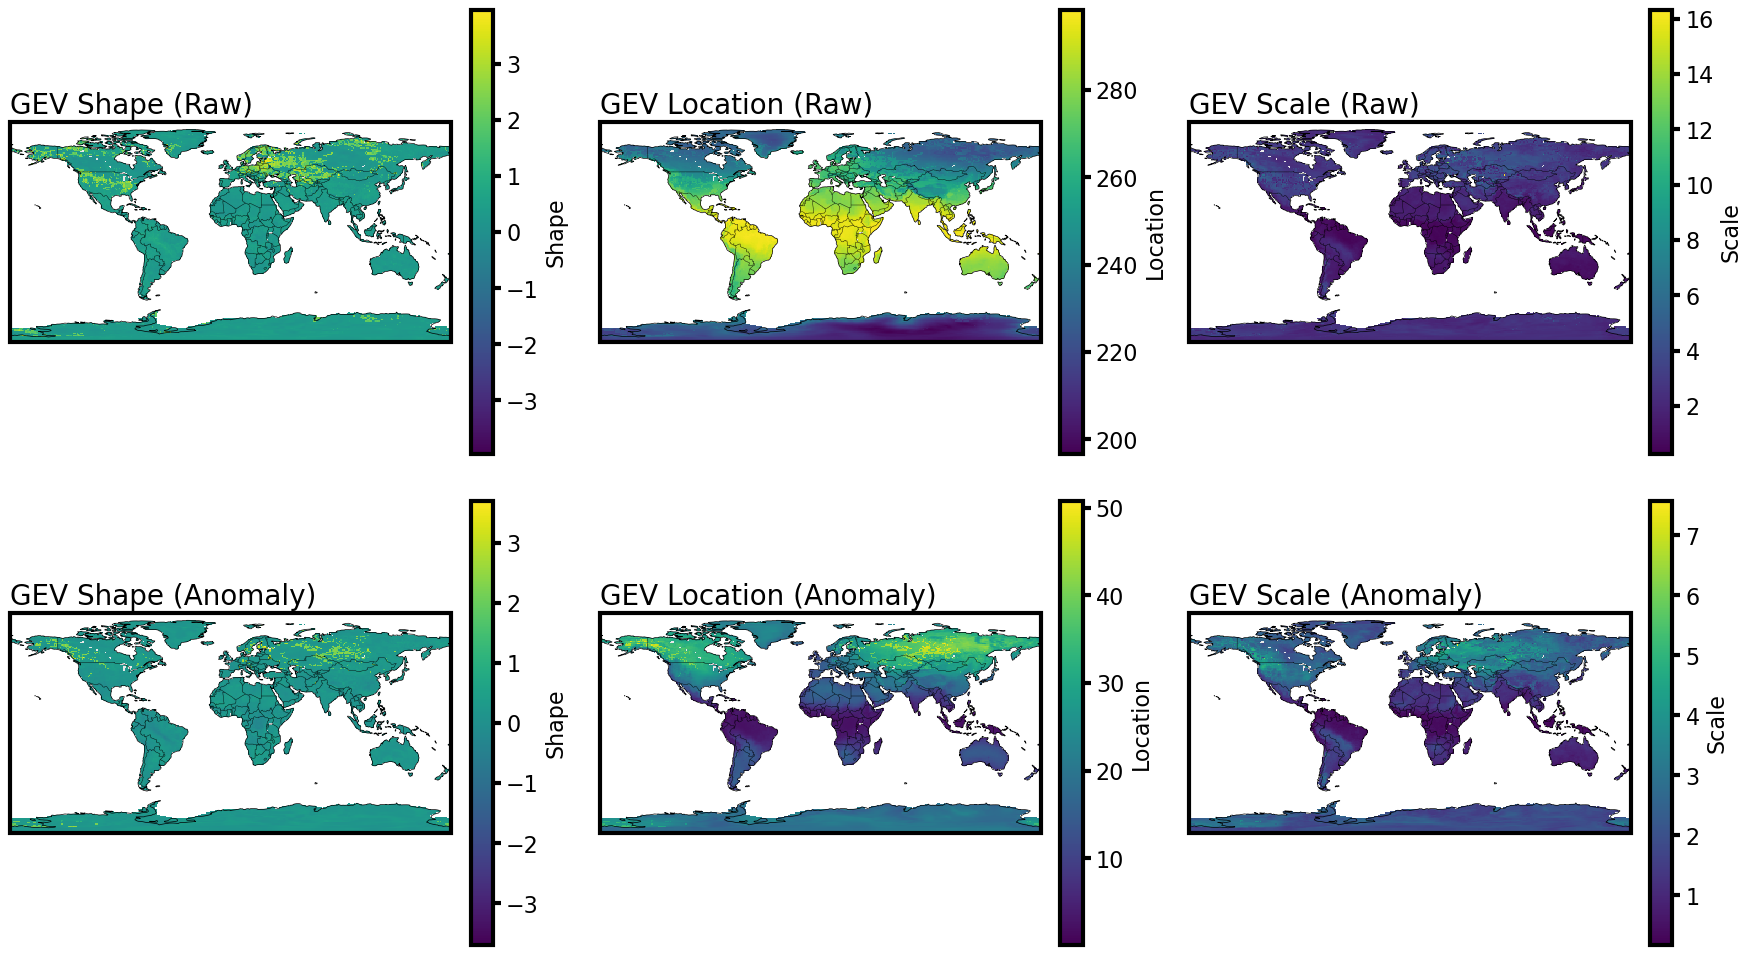

In [19]:
plot_gev_parameters(ds_max, save_fig=False, filename_args=['gev-params-raw-anom', 'png', 'figs'])

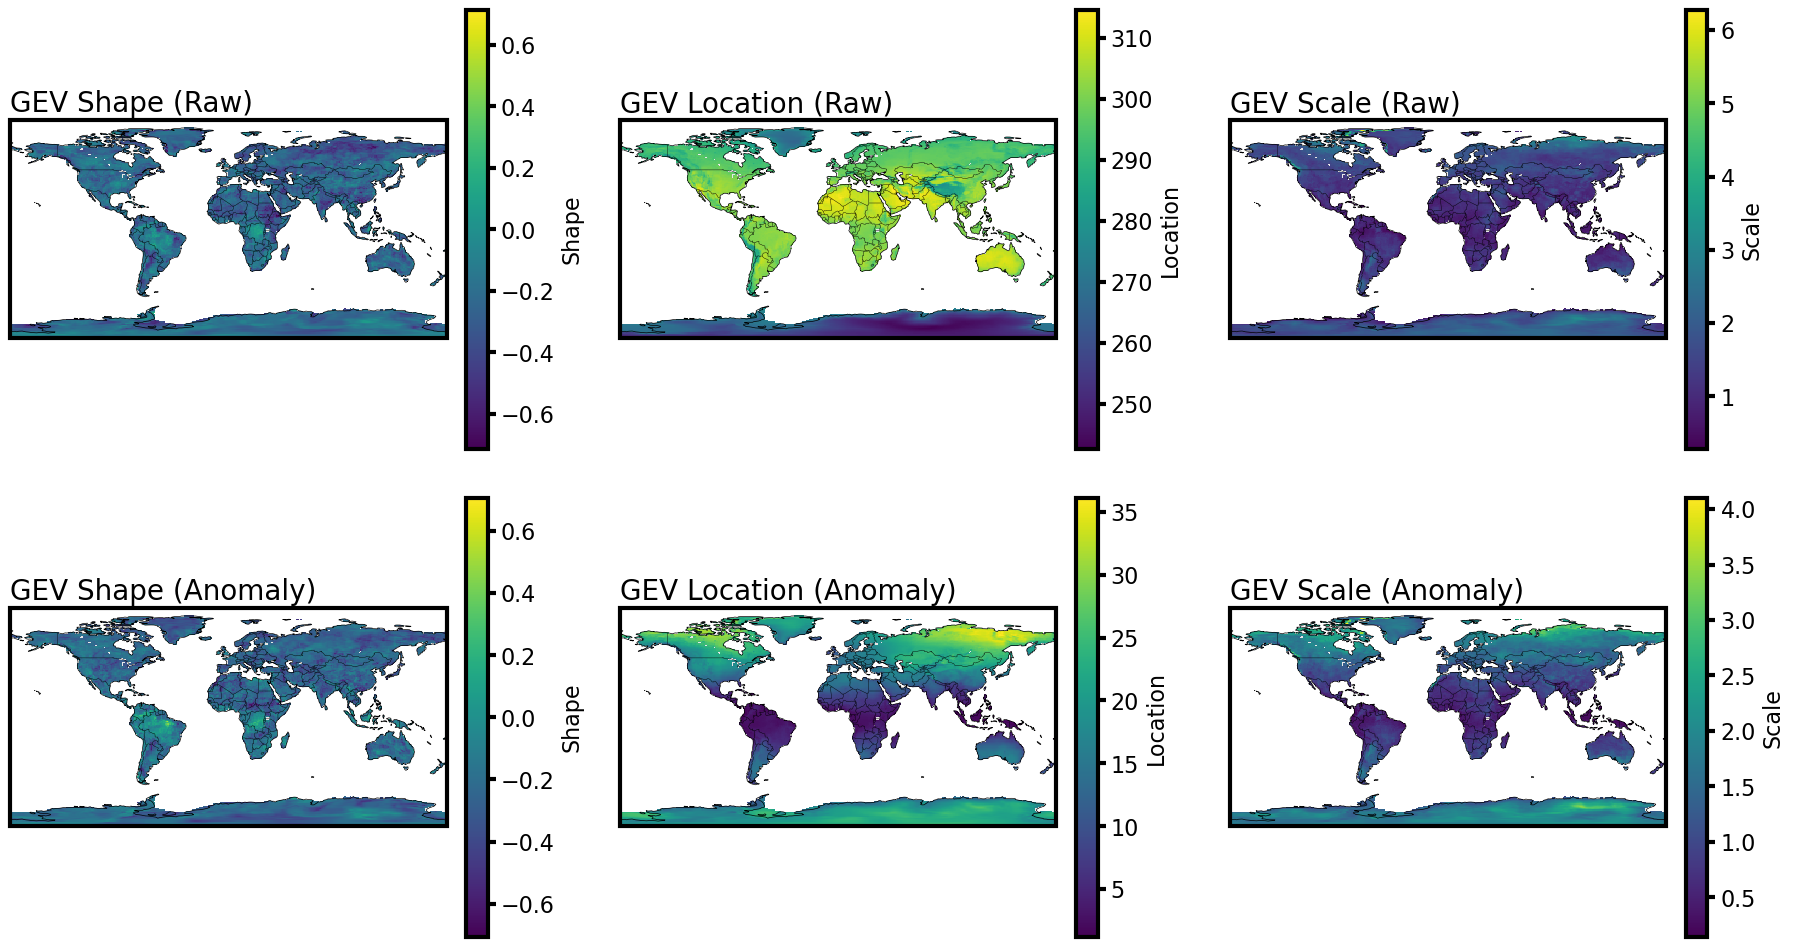

In [20]:
plot_gev_parameters(ds_max_mle, save_fig=False, filename_args=['gev-params-raw-anom', 'png', 'figs'], whoops=True)